# Quick EDA: Google Ads Demographic Targeting Analysis

This notebook provides a quick analysis of demographic targeting in Google political ads, focusing on:
- Age targeting availability and distribution
- Gender targeting availability and distribution  
- Race targeting availability and distribution
- Assessment of whether the data is suitable for demographic analysis

## Dataset Overview
- **Source**: Google Ad Transparency 2022 - Variables Dataset
- **Purpose**: Assess demographic targeting data quality and availability


In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from collections import Counter

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_colwidth', 100)

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")


Libraries imported successfully!


In [2]:
# Load the Google variables dataset
data_path = '../../data/google/g2022_adid_var_031325.csv'
df = pd.read_csv(data_path, low_memory=False)

print("=" * 80)
print("DATASET LOADING")
print("=" * 80)
print(f"Dataset shape: {df.shape}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"Columns: {len(df.columns)}")
print(f"Rows: {len(df):,}")

# Check for demographic targeting columns
demographic_cols = ['age_targeting', 'gender_targeting', 'race_of_focus']
print(f"\nDemographic targeting columns:")
for col in demographic_cols:
    exists = col in df.columns
    print(f"  {col}: {'✓ Found' if exists else '✗ Not found'}")


DATASET LOADING
Dataset shape: (80247, 57)
Memory usage: 216.10 MB
Columns: 57
Rows: 80,247

Demographic targeting columns:
  age_targeting: ✓ Found
  gender_targeting: ✓ Found
  race_of_focus: ✓ Found


AGE TARGETING ANALYSIS

Total ads: 80,247
Missing age_targeting: 41,896 (52.2%)
Empty age_targeting: 0 (0.0%)
Has age_targeting: 38,351 (47.8%)

Age range distribution (from 38,351 ads with targeting):
Total age range mentions: 214,284

Most common age ranges:
  45-54          : 34,786 ads ( 90.7%)
  35-44          : 34,734 ads ( 90.6%)
  55-64          : 33,061 ads ( 86.2%)
  ≥65            : 32,785 ads ( 85.5%)
  25-34          : 30,341 ads ( 79.1%)
  18-24          : 25,969 ads ( 67.7%)
  Unknown age    : 22,608 ads ( 59.0%)


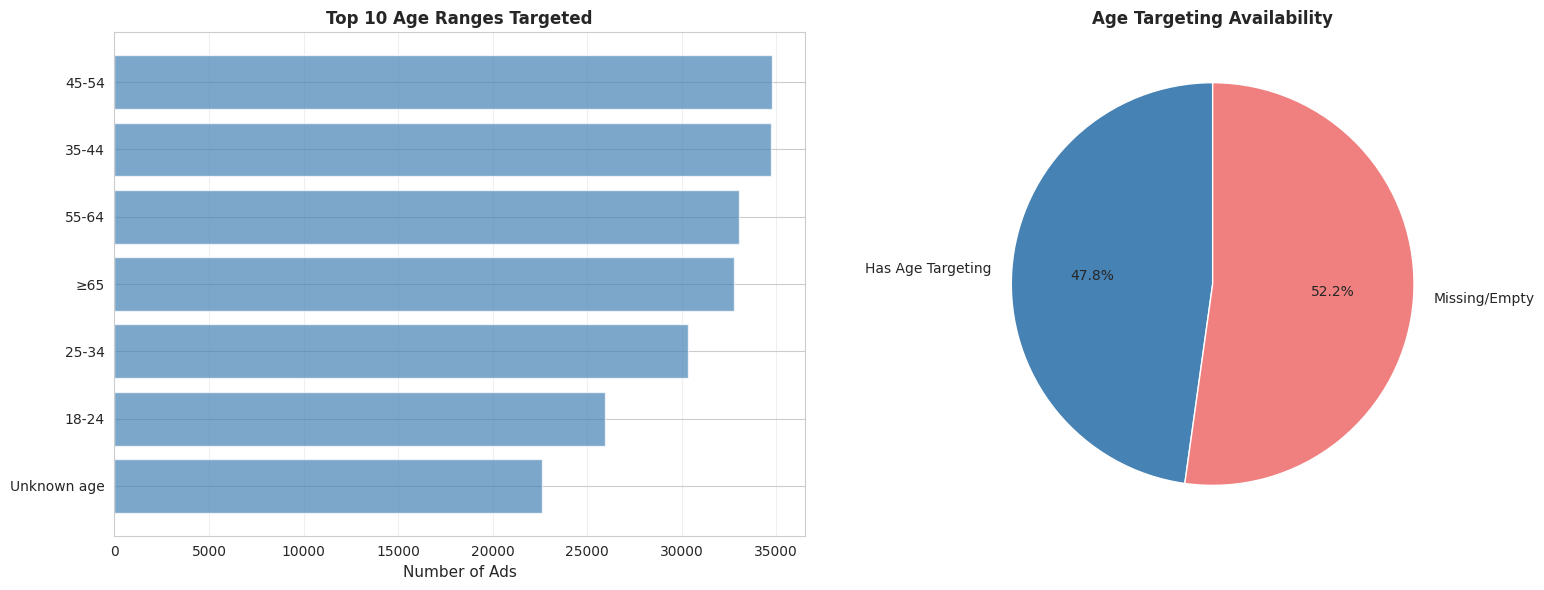

In [3]:
# AGE TARGETING ANALYSIS
print("=" * 80)
print("AGE TARGETING ANALYSIS")
print("=" * 80)

if 'age_targeting' in df.columns:
    # Check missing values
    total_ads = len(df)
    missing_age = df['age_targeting'].isna().sum()
    empty_age = (df['age_targeting'].astype(str).str.strip() == '').sum()
    has_age = df['age_targeting'].notna() & (df['age_targeting'].astype(str).str.strip() != '')
    has_age_count = has_age.sum()
    
    print(f"\nTotal ads: {total_ads:,}")
    print(f"Missing age_targeting: {missing_age:,} ({missing_age/total_ads*100:.1f}%)")
    print(f"Empty age_targeting: {empty_age:,} ({empty_age/total_ads*100:.1f}%)")
    print(f"Has age_targeting: {has_age_count:,} ({has_age_count/total_ads*100:.1f}%)")
    
    # Analyze age targeting values
    if has_age_count > 0:
        age_targeting_data = df[has_age]['age_targeting'].copy()
        
        # Parse age ranges (they're comma-separated)
        all_age_ranges = []
        for age_str in age_targeting_data:
            if pd.notna(age_str) and str(age_str).strip() != '':
                # Split by comma and clean
                ranges = [r.strip() for r in str(age_str).split(',')]
                all_age_ranges.extend(ranges)
        
        age_range_counts = Counter(all_age_ranges)
        
        print(f"\nAge range distribution (from {has_age_count:,} ads with targeting):")
        print(f"Total age range mentions: {len(all_age_ranges):,}")
        print(f"\nMost common age ranges:")
        for age_range, count in age_range_counts.most_common():
            pct = (count / has_age_count) * 100
            print(f"  {age_range:15s}: {count:6,} ads ({pct:5.1f}%)")
        
        # Visualize
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        
        # Age range frequency
        top_ages = dict(age_range_counts.most_common(10))
        axes[0].barh(list(top_ages.keys()), list(top_ages.values()), color='steelblue', alpha=0.7)
        axes[0].set_xlabel('Number of Ads', fontsize=11)
        axes[0].set_title('Top 10 Age Ranges Targeted', fontsize=12, fontweight='bold')
        axes[0].invert_yaxis()
        axes[0].grid(True, alpha=0.3, axis='x')
        
        # Availability pie chart
        availability = [has_age_count, missing_age + empty_age]
        labels = ['Has Age Targeting', 'Missing/Empty']
        colors = ['steelblue', 'lightcoral']
        axes[1].pie(availability, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90)
        axes[1].set_title('Age Targeting Availability', fontsize=12, fontweight='bold')
        
        plt.tight_layout()
        plt.show()
    else:
        print("\n⚠️  No age targeting data available")
else:
    print("⚠️  'age_targeting' column not found")


GENDER TARGETING ANALYSIS

Total ads: 80,247
Missing gender_targeting: 47,329 (59.0%)
Empty gender_targeting: 0 (0.0%)
Has gender_targeting: 32,918 (41.0%)

Gender distribution (from 32,918 ads with targeting):
Total gender mentions: 88,021

Gender targeting breakdown:
  Female              : 31,133 ads ( 94.6%)
  Male                : 29,085 ads ( 88.4%)
  Unknown gender      : 27,803 ads ( 84.5%)


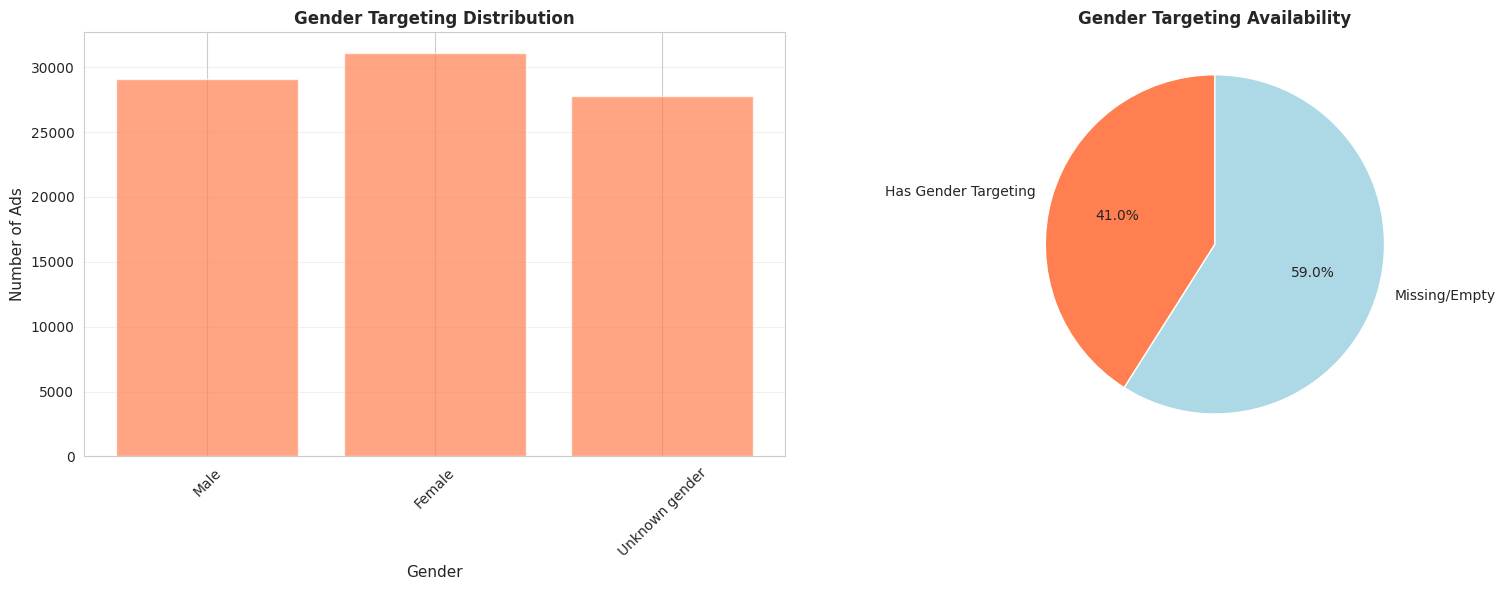

In [4]:
# GENDER TARGETING ANALYSIS
print("=" * 80)
print("GENDER TARGETING ANALYSIS")
print("=" * 80)

if 'gender_targeting' in df.columns:
    # Check missing values
    total_ads = len(df)
    missing_gender = df['gender_targeting'].isna().sum()
    empty_gender = (df['gender_targeting'].astype(str).str.strip() == '').sum()
    has_gender = df['gender_targeting'].notna() & (df['gender_targeting'].astype(str).str.strip() != '')
    has_gender_count = has_gender.sum()
    
    print(f"\nTotal ads: {total_ads:,}")
    print(f"Missing gender_targeting: {missing_gender:,} ({missing_gender/total_ads*100:.1f}%)")
    print(f"Empty gender_targeting: {empty_gender:,} ({empty_gender/total_ads*100:.1f}%)")
    print(f"Has gender_targeting: {has_gender_count:,} ({has_gender_count/total_ads*100:.1f}%)")
    
    # Analyze gender targeting values
    if has_gender_count > 0:
        gender_targeting_data = df[has_gender]['gender_targeting'].copy()
        
        # Parse gender values (they're comma-separated)
        all_genders = []
        for gender_str in gender_targeting_data:
            if pd.notna(gender_str) and str(gender_str).strip() != '':
                # Split by comma and clean
                genders = [g.strip() for g in str(gender_str).split(',')]
                all_genders.extend(genders)
        
        gender_counts = Counter(all_genders)
        
        print(f"\nGender distribution (from {has_gender_count:,} ads with targeting):")
        print(f"Total gender mentions: {len(all_genders):,}")
        print(f"\nGender targeting breakdown:")
        for gender, count in gender_counts.most_common():
            pct = (count / has_gender_count) * 100
            print(f"  {gender:20s}: {count:6,} ads ({pct:5.1f}%)")
        
        # Visualize
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        
        # Gender frequency
        axes[0].bar(gender_counts.keys(), gender_counts.values(), color='coral', alpha=0.7)
        axes[0].set_xlabel('Gender', fontsize=11)
        axes[0].set_ylabel('Number of Ads', fontsize=11)
        axes[0].set_title('Gender Targeting Distribution', fontsize=12, fontweight='bold')
        axes[0].tick_params(axis='x', rotation=45)
        axes[0].grid(True, alpha=0.3, axis='y')
        
        # Availability pie chart
        availability = [has_gender_count, missing_gender + empty_gender]
        labels = ['Has Gender Targeting', 'Missing/Empty']
        colors = ['coral', 'lightblue']
        axes[1].pie(availability, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90)
        axes[1].set_title('Gender Targeting Availability', fontsize=12, fontweight='bold')
        
        plt.tight_layout()
        plt.show()
    else:
        print("\n⚠️  No gender targeting data available")
else:
    print("⚠️  'gender_targeting' column not found")


RACE TARGETING ANALYSIS

Total ads: 80,247
Missing race_of_focus: 4,966 (6.2%)
Empty race_of_focus: 0 (0.0%)
Has race_of_focus: 75,281 (93.8%)

Race of focus distribution:
Unique race values: 407

Race targeting breakdown:
  No race of focus              : 47,290 ads ( 58.9%)
  Downballot                    : 11,493 ads ( 14.3%)
  NVS0                          :    768 ads (  1.0%)
  AK00                          :    651 ads (  0.8%)
  PAS0                          :    635 ads (  0.8%)
  GAS0                          :    567 ads (  0.7%)
  AZS0                          :    536 ads (  0.7%)
  WIS0                          :    463 ads (  0.6%)
  NV01                          :    378 ads (  0.5%)
  UTS0                          :    344 ads (  0.4%)
  NCS0                          :    337 ads (  0.4%)
  MI07                          :    265 ads (  0.3%)
  NV03                          :    260 ads (  0.3%)
  CA11                          :    247 ads (  0.3%)
  CA47               

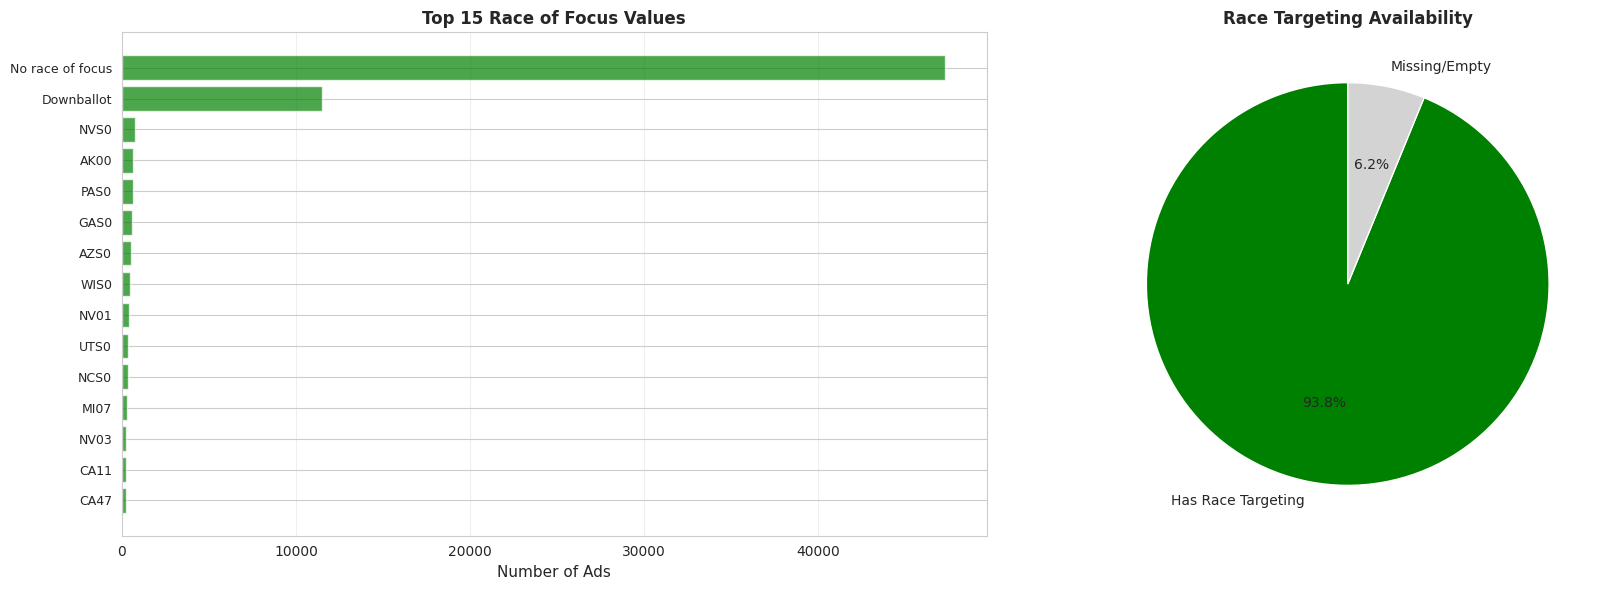

In [5]:
# RACE TARGETING ANALYSIS
print("=" * 80)
print("RACE TARGETING ANALYSIS")
print("=" * 80)

if 'race_of_focus' in df.columns:
    # Check missing values
    total_ads = len(df)
    missing_race = df['race_of_focus'].isna().sum()
    empty_race = (df['race_of_focus'].astype(str).str.strip() == '').sum()
    has_race = df['race_of_focus'].notna() & (df['race_of_focus'].astype(str).str.strip() != '')
    has_race_count = has_race.sum()
    
    print(f"\nTotal ads: {total_ads:,}")
    print(f"Missing race_of_focus: {missing_race:,} ({missing_race/total_ads*100:.1f}%)")
    print(f"Empty race_of_focus: {empty_race:,} ({empty_race/total_ads*100:.1f}%)")
    print(f"Has race_of_focus: {has_race_count:,} ({has_race_count/total_ads*100:.1f}%)")
    
    # Analyze race targeting values
    if has_race_count > 0:
        race_data = df[has_race]['race_of_focus'].copy()
        race_counts = race_data.value_counts()
        
        print(f"\nRace of focus distribution:")
        print(f"Unique race values: {race_data.nunique()}")
        print(f"\nRace targeting breakdown:")
        for race, count in race_counts.items():
            pct = (count / total_ads) * 100
            print(f"  {str(race):30s}: {count:6,} ads ({pct:5.1f}%)")
        
        # Visualize
        fig, axes = plt.subplots(1, 2, figsize=(18, 6))
        
        # Race frequency (top 15)
        top_races = race_counts.head(15)
        axes[0].barh(range(len(top_races)), top_races.values, color='green', alpha=0.7)
        axes[0].set_yticks(range(len(top_races)))
        axes[0].set_yticklabels(top_races.index, fontsize=9)
        axes[0].set_xlabel('Number of Ads', fontsize=11)
        axes[0].set_title('Top 15 Race of Focus Values', fontsize=12, fontweight='bold')
        axes[0].invert_yaxis()
        axes[0].grid(True, alpha=0.3, axis='x')
        
        # Availability pie chart
        availability = [has_race_count, missing_race + empty_race]
        labels = ['Has Race Targeting', 'Missing/Empty']
        colors = ['green', 'lightgray']
        axes[1].pie(availability, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90)
        axes[1].set_title('Race Targeting Availability', fontsize=12, fontweight='bold')
        
        plt.tight_layout()
        plt.show()
    else:
        print("\n⚠️  No race targeting data available")
else:
    print("⚠️  'race_of_focus' column not found")


COMBINED DEMOGRAPHIC TARGETING ANALYSIS

Demographic Targeting Combinations:
  Has ANY demographic targeting: 79,830 (99.5%)
  Has ALL demographic targeting: 27,387 (34.1%)
  Has age + gender: 31,249 (38.9%)
  Has age + race: 33,802 (42.1%)
  Has gender + race: 29,056 (36.2%)
  Has ONLY age: 687
  Has ONLY gender: 0
  Has ONLY race: 39,810
  Has NO demographic targeting: 417 (0.5%)


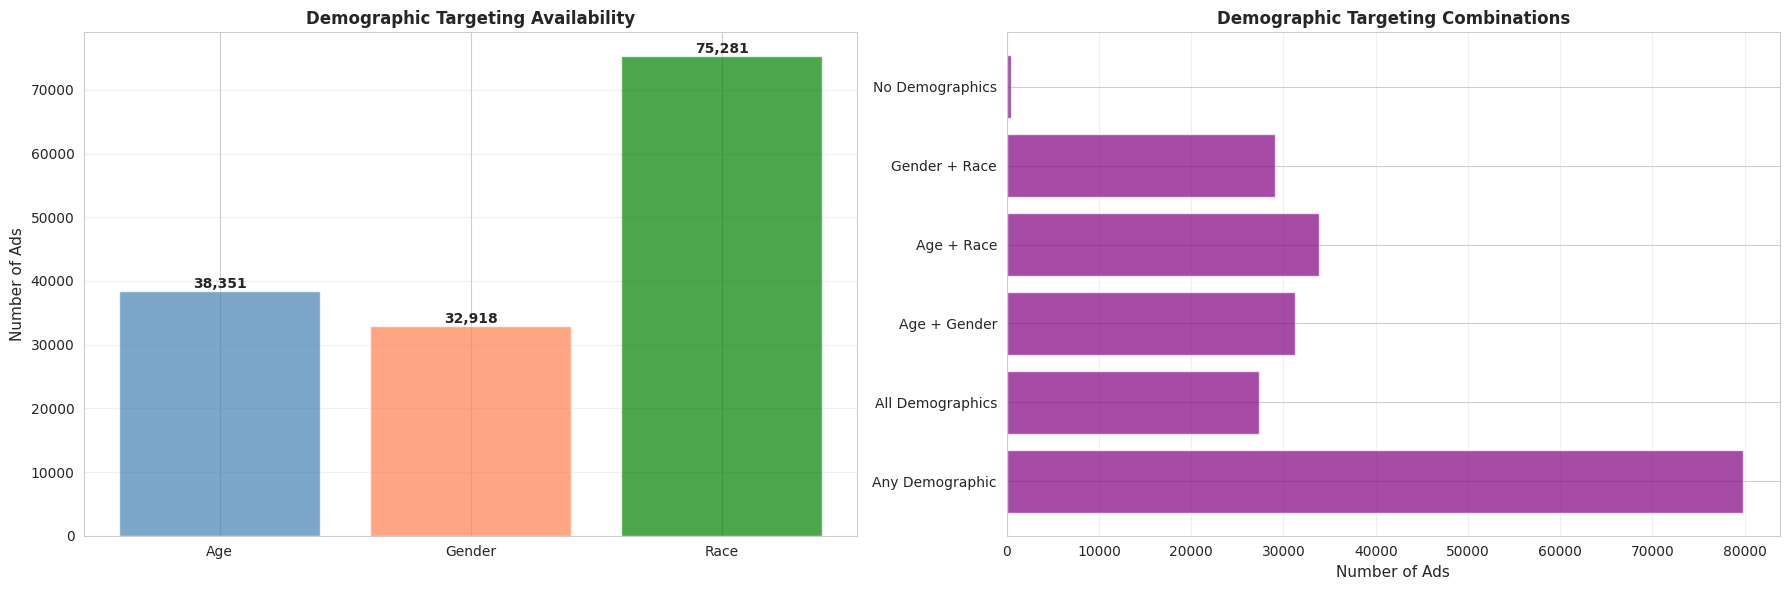

In [6]:
# COMBINED DEMOGRAPHIC TARGETING ANALYSIS
print("=" * 80)
print("COMBINED DEMOGRAPHIC TARGETING ANALYSIS")
print("=" * 80)

# Check which ads have demographic targeting
total_ads = len(df)

has_age = df['age_targeting'].notna() & (df['age_targeting'].astype(str).str.strip() != '') if 'age_targeting' in df.columns else pd.Series([False] * len(df))
has_gender = df['gender_targeting'].notna() & (df['gender_targeting'].astype(str).str.strip() != '') if 'gender_targeting' in df.columns else pd.Series([False] * len(df))
has_race = df['race_of_focus'].notna() & (df['race_of_focus'].astype(str).str.strip() != '') if 'race_of_focus' in df.columns else pd.Series([False] * len(df))

# Combinations
has_any_demo = has_age | has_gender | has_race
has_all_demo = has_age & has_gender & has_race
has_age_gender = has_age & has_gender
has_age_race = has_age & has_race
has_gender_race = has_gender & has_race

print(f"\nDemographic Targeting Combinations:")
print(f"  Has ANY demographic targeting: {has_any_demo.sum():,} ({has_any_demo.sum()/total_ads*100:.1f}%)")
print(f"  Has ALL demographic targeting: {has_all_demo.sum():,} ({has_all_demo.sum()/total_ads*100:.1f}%)")
print(f"  Has age + gender: {has_age_gender.sum():,} ({has_age_gender.sum()/total_ads*100:.1f}%)")
print(f"  Has age + race: {has_age_race.sum():,} ({has_age_race.sum()/total_ads*100:.1f}%)")
print(f"  Has gender + race: {has_gender_race.sum():,} ({has_gender_race.sum()/total_ads*100:.1f}%)")
print(f"  Has ONLY age: {(has_age & ~has_gender & ~has_race).sum():,}")
print(f"  Has ONLY gender: {(has_gender & ~has_age & ~has_race).sum():,}")
print(f"  Has ONLY race: {(has_race & ~has_age & ~has_gender).sum():,}")
print(f"  Has NO demographic targeting: {(~has_any_demo).sum():,} ({(~has_any_demo).sum()/total_ads*100:.1f}%)")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Venn-like comparison
categories = ['Age', 'Gender', 'Race']
counts = [has_age.sum(), has_gender.sum(), has_race.sum()]
colors = ['steelblue', 'coral', 'green']

axes[0].bar(categories, counts, color=colors, alpha=0.7)
axes[0].set_ylabel('Number of Ads', fontsize=11)
axes[0].set_title('Demographic Targeting Availability', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(counts):
    axes[0].text(i, v, f'{v:,}', ha='center', va='bottom', fontweight='bold')

# Combination breakdown
combination_data = {
    'Any Demographic': has_any_demo.sum(),
    'All Demographics': has_all_demo.sum(),
    'Age + Gender': has_age_gender.sum(),
    'Age + Race': has_age_race.sum(),
    'Gender + Race': has_gender_race.sum(),
    'No Demographics': (~has_any_demo).sum()
}

axes[1].barh(list(combination_data.keys()), list(combination_data.values()), color='purple', alpha=0.7)
axes[1].set_xlabel('Number of Ads', fontsize=11)
axes[1].set_title('Demographic Targeting Combinations', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()


In [7]:
# SAMPLE ADS WITH DEMOGRAPHIC TARGETING
print("=" * 80)
print("SAMPLE ADS WITH DEMOGRAPHIC TARGETING")
print("=" * 80)

# Show examples of ads with different demographic targeting
samples = {
    'Has all demographics': df[has_all_demo].head(5) if has_all_demo.sum() > 0 else pd.DataFrame(),
    'Has age + gender': df[has_age_gender & ~has_race].head(5) if (has_age_gender & ~has_race).sum() > 0 else pd.DataFrame(),
    'Has race targeting': df[has_race].head(5) if has_race.sum() > 0 else pd.DataFrame()
}

for category, sample_df in samples.items():
    if len(sample_df) > 0:
        print(f"\n{'='*100}")
        print(f"CATEGORY: {category}")
        print(f"{'='*100}")
        
        for idx, (row_idx, row) in enumerate(sample_df.iterrows(), 1):
            print(f"\n--- Example {idx} ---")
            print(f"Ad ID: {row.get('ad_id', 'N/A')}")
            print(f"Advertiser: {row.get('advertiser_name', 'N/A')}")
            print(f"Ad Type: {row.get('ad_type', 'N/A')}")
            
            if 'age_targeting' in df.columns and pd.notna(row.get('age_targeting')) and str(row['age_targeting']).strip() != '':
                print(f"  Age Targeting: {row['age_targeting']}")
            
            if 'gender_targeting' in df.columns and pd.notna(row.get('gender_targeting')) and str(row['gender_targeting']).strip() != '':
                print(f"  Gender Targeting: {row['gender_targeting']}")
            
            if 'race_of_focus' in df.columns and pd.notna(row.get('race_of_focus')) and str(row['race_of_focus']).strip() != '':
                print(f"  Race of Focus: {row['race_of_focus']}")
            
            print("-" * 100)


SAMPLE ADS WITH DEMOGRAPHIC TARGETING

CATEGORY: Has all demographics

--- Example 1 ---
Ad ID: CR00000257354440376321
Advertiser: Abrams For Governor
Ad Type: VIDEO
  Age Targeting: 18-24, 25-34, 35-44, 45-54, 55-64, ≥65
  Gender Targeting: Male, Female, Unknown gender
  Race of Focus: Downballot
----------------------------------------------------------------------------------------------------

--- Example 2 ---
Ad ID: CR00001130641550737409
Advertiser: HOUSE REPUBLICAN CAMPAIGN COMMITTEE
Ad Type: VIDEO
  Age Targeting: 18-24, 25-34, 35-44, 45-54, 55-64, ≥65, Unknown age
  Gender Targeting: Male, Female, Unknown gender
  Race of Focus: No race of focus
----------------------------------------------------------------------------------------------------

--- Example 3 ---
Ad ID: CR00001915967730876417
Advertiser: WARNOCK FOR GEORGIA
Ad Type: VIDEO
  Age Targeting: 35-44, 45-54, 55-64, ≥65, Unknown age
  Gender Targeting: Male, Female, Unknown gender
  Race of Focus: No race of focus
-

## Summary and Assessment

### Demographic Targeting Data Availability

1. **Age Targeting:**
   - Percentage of ads with age targeting data
   - Distribution of age ranges targeted
   - Most common age groups

2. **Gender Targeting:**
   - Percentage of ads with gender targeting data
   - Distribution of gender targeting
   - Most common gender targets

3. **Race Targeting:**
   - Percentage of ads with race targeting data
   - Distribution of race of focus values
   - Most common race targets

### Assessment for Analysis

**✅ SUITABLE FOR ANALYSIS IF:**
- >30% of ads have demographic targeting data
- Multiple demographic categories are available
- Data quality is consistent

**⚠️ LIMITED ANALYSIS IF:**
- <30% of ads have demographic targeting
- Only one demographic category available
- High missing data rates

**❌ NOT SUITABLE IF:**
- <10% of ads have demographic targeting
- Data is mostly missing or empty
- Inconsistent data format


In [8]:
# FINAL ASSESSMENT FOR DEMOGRAPHIC ANALYSIS
print("=" * 80)
print("FINAL ASSESSMENT: IS THIS DATA SUITABLE FOR DEMOGRAPHIC ANALYSIS?")
print("=" * 80)

total_ads = len(df)

# Calculate percentages
age_pct = (has_age.sum() / total_ads * 100) if 'age_targeting' in df.columns else 0
gender_pct = (has_gender.sum() / total_ads * 100) if 'gender_targeting' in df.columns else 0
race_pct = (has_race.sum() / total_ads * 100) if 'race_of_focus' in df.columns else 0
any_demo_pct = (has_any_demo.sum() / total_ads * 100) if 'age_targeting' in df.columns or 'gender_targeting' in df.columns or 'race_of_focus' in df.columns else 0

print(f"\n📊 DATA AVAILABILITY SUMMARY:")
print(f"  Age targeting: {has_age.sum():,} ads ({age_pct:.1f}%)")
print(f"  Gender targeting: {has_gender.sum():,} ads ({gender_pct:.1f}%)")
print(f"  Race targeting: {has_race.sum():,} ads ({race_pct:.1f}%)")
print(f"  Any demographic: {has_any_demo.sum():,} ads ({any_demo_pct:.1f}%)")

print(f"\n🎯 ASSESSMENT:")
if any_demo_pct >= 50:
    verdict = "✅ HIGHLY SUITABLE"
    reason = f"More than 50% of ads have demographic targeting data"
elif any_demo_pct >= 30:
    verdict = "✅ SUITABLE"
    reason = f"30-50% of ads have demographic targeting data - sufficient for analysis"
elif any_demo_pct >= 10:
    verdict = "⚠️  PARTIALLY SUITABLE"
    reason = f"10-30% of ads have demographic targeting - limited but usable"
else:
    verdict = "❌ LIMITED SUITABILITY"
    reason = f"Less than 10% of ads have demographic targeting - very limited analysis possible"

print(f"\n{verdict}")
print(f"Reason: {reason}")

print(f"\n📋 RECOMMENDATIONS:")
if any_demo_pct >= 30:
    print("  ✓ Dataset is suitable for demographic targeting analysis")
    print("  ✓ Can analyze age, gender, and race targeting patterns")
    print("  ✓ Can study targeting strategies and manipulation through demographics")
    print("  ✓ Consider combining with other features (spending, party, etc.)")
elif any_demo_pct >= 10:
    print("  ⚠️  Dataset can be used but with limitations")
    print("  ⚠️  May need to focus on ads with demographic data only")
    print("  ⚠️  Consider supplementing with other targeting features")
    print("  ⚠️  Statistical power may be limited")
else:
    print("  ❌ Dataset has very limited demographic targeting data")
    print("  ❌ May need to rely on other features for analysis")
    print("  ❌ Consider if demographic analysis is feasible with this dataset")

# Specific recommendations by demographic
print(f"\n📊 BY DEMOGRAPHIC CATEGORY:")
if age_pct >= 30:
    print(f"  ✓ Age targeting: SUITABLE ({age_pct:.1f}% available)")
elif age_pct >= 10:
    print(f"  ⚠️  Age targeting: LIMITED ({age_pct:.1f}% available)")
else:
    print(f"  ❌ Age targeting: NOT SUITABLE ({age_pct:.1f}% available)")

if gender_pct >= 30:
    print(f"  ✓ Gender targeting: SUITABLE ({gender_pct:.1f}% available)")
elif gender_pct >= 10:
    print(f"  ⚠️  Gender targeting: LIMITED ({gender_pct:.1f}% available)")
else:
    print(f"  ❌ Gender targeting: NOT SUITABLE ({gender_pct:.1f}% available)")

if race_pct >= 30:
    print(f"  ✓ Race targeting: SUITABLE ({race_pct:.1f}% available)")
elif race_pct >= 10:
    print(f"  ⚠️  Race targeting: LIMITED ({race_pct:.1f}% available)")
else:
    print(f"  ❌ Race targeting: NOT SUITABLE ({race_pct:.1f}% available)")

print(f"\n{'='*80}")


FINAL ASSESSMENT: IS THIS DATA SUITABLE FOR DEMOGRAPHIC ANALYSIS?

📊 DATA AVAILABILITY SUMMARY:
  Age targeting: 38,351 ads (47.8%)
  Gender targeting: 32,918 ads (41.0%)
  Race targeting: 75,281 ads (93.8%)
  Any demographic: 79,830 ads (99.5%)

🎯 ASSESSMENT:

✅ HIGHLY SUITABLE
Reason: More than 50% of ads have demographic targeting data

📋 RECOMMENDATIONS:
  ✓ Dataset is suitable for demographic targeting analysis
  ✓ Can analyze age, gender, and race targeting patterns
  ✓ Can study targeting strategies and manipulation through demographics
  ✓ Consider combining with other features (spending, party, etc.)

📊 BY DEMOGRAPHIC CATEGORY:
  ✓ Age targeting: SUITABLE (47.8% available)
  ✓ Gender targeting: SUITABLE (41.0% available)
  ✓ Race targeting: SUITABLE (93.8% available)

